# LangGraph website safety workflow

This notebook builds a small LangGraph app that:

1. Checks a website URL with [Google Web Risk](https://cloud.google.com/web-risk)
2. Calls an LLM only if the URL is marked safe
3. Otherwise returns a fallback message without calling the model

Flow: `START → safety_check → generate_response | fallback → END`

## Import needed libraries

The next cell loads:

- Standard library helpers for HTTP, JSON, URL parsing, and typing
- `load_dotenv` to read API keys from a `.env` file
- `ChatGroq` if you later switch the LLM node to Groq
- `StateGraph`, `START`, and `END` from LangGraph, which wire nodes into a compiled graph


In [45]:
from __future__ import annotations

import os
import base64
import requests
import json
from typing import Literal, Dict
from urllib.error import HTTPError, URLError
from urllib.parse import urlencode, urlparse
from urllib.request import urlopen
from typing_extensions import TypedDict

from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langgraph.graph import END, START, StateGraph


## Define state

`WorkflowState` is the shared memory passed between nodes. Each node reads from it and returns a **partial update** (only the keys it changes).

| Field | Role |
| --- | --- |
| `website_url` | URL to check |
| `user_request` | What the user wants to know about the site |
| `safety_status` | `"safe"` or `"unsafe"` after the reputation check |
| `safety_reason` | Why the check passed or failed |
| `response` | Final message returned to the user |

`total=False` makes every field optional so nodes do not have to populate the whole dict.

In [46]:
class WorkflowState(TypedDict, total=False):

    website_url: str
    user_request: str
    safety_status: Literal["safe", "unsafe"]
    safety_reason: str
    response: str

## Define and compile the graph

The next cells define three **nodes**, one **router**, then compile them into a graph.

A node is a function that takes `WorkflowState` and returns a partial update. LangGraph merges that update into the shared state before the next step.

### Node: `safety_check`

This is the first node after `START`. It never calls an LLM.

1. Rejects URLs that are not `http`/`https` or have no host
2. Requires `GOOGLE_WEB_RISK_API_KEY`; if it is missing, the URL is treated as unsafe
3. Queries Google Web Risk for `MALWARE`, `SOCIAL_ENGINEERING`, and `UNWANTED_SOFTWARE`
4. Treats HTTP/network failures as unsafe (fail closed)
5. Sets `safety_status` to `"unsafe"` if any of those threats are listed, otherwise `"safe"`

The return value is only `safety_status` and `safety_reason`. Later nodes read those fields.

In [47]:
def safety_check(state: Dict) -> Dict:
    """Step 1: check a website's reputation with VirusTotal."""
    url = state["website_url"].strip()
    parsed = urlparse(url)
    if parsed.scheme not in {"http", "https"} or not parsed.netloc:
        return {"safety_status": "unsafe", "safety_reason": "The website URL is invalid."}

    api_key = os.getenv("VIRUSTOTAL_API_KEY")
    if not api_key:
        return {
            "safety_status": "unsafe",
            "safety_reason": "Website reputation checking is not configured.",
        }

    headers = {"x-apikey": api_key}

    try:
        # Step 1: Submit URL for scanning
        submit_url = "https://www.virustotal.com/api/v3/urls"
        response = requests.post(submit_url, headers=headers, data={"url": url}, timeout=10)
        response.raise_for_status()
        analysis_id = response.json()["data"]["id"]

        # Step 2: Retrieve analysis results
        analysis_url = f"https://www.virustotal.com/api/v3/analyses/{analysis_id}"
        result = requests.get(analysis_url, headers=headers, timeout=10).json()

    except requests.RequestException as error:
        return {
            "safety_status": "unsafe",
            "safety_reason": f"Reputation service could not verify this URL: {error}.",
        }

    stats = result.get("data", {}).get("attributes", {}).get("stats", {})
    malicious = stats.get("malicious", 0)
    suspicious = stats.get("suspicious", 0)

    if malicious > 0 or suspicious > 0:
        return {
            "safety_status": "unsafe",
            "safety_reason": (
                f"This site appears risky based on {malicious} malicious "
                f"and {suspicious} suspicious reports."
            ),
        }

    return {
        "safety_status": "safe",
        "safety_reason": "No significant threats were detected for this site.",
    }


### Router: `route_after_safety`

This function is **not** a graph node. It is passed to `add_conditional_edges` after `safety_check`.

- `"safe"` → `generate_response`
- anything else → `fallback`

The return value must match a node name that was registered on the builder.

In [48]:
def route_after_safety(state: WorkflowState) -> Literal["generate_response", "fallback"]:
    """Step 2: choose the next node from the safety result."""
    return "generate_response" if state["safety_status"] == "safe" else "fallback"

### Node: `generate_response`

Reached only when `safety_status` is `"safe"`. This is the only LLM call in the graph.

The prompt includes the URL and `user_request`, and tells the model not to claim it visited the site. The node writes `response` from `message.content`.

This cell uses `ChatOpenAI` (`gpt-4.1-mini`). The import cell currently loads `ChatGroq` instead, so this will fail until those match (import `ChatOpenAI`, or switch this node to Groq).

In [49]:
def generate_response(state: WorkflowState) -> WorkflowState:
    """Step 3: call the LLM only for queries marked safe."""
    model = ChatGroq(model="llama3-8b-8192", temperature=0)
    prompt = (
        f"The website {state['website_url']} passed a reputation check. "
        f"The user asks: {state['user_request']}\n\n"
        "Answer helpfully, but do not claim you visited or inspected the website."
    )
    message = model.invoke(prompt)
    return {"response": message.content}

### Node: `fallback`

Reached when the URL is invalid, the reputation check is not configured, the API errors, or Web Risk lists a threat.

It does **not** call a model. It writes `response` from `safety_reason` so the user still gets an explanation.

In [50]:
def fallback(state: WorkflowState) -> WorkflowState:
    """Return a safe alternative without calling the LLM."""
    return {
        "response": (
            f"I won't process that website. {state['safety_reason']}"
        )
    }

### Compile: `build_graph`

`StateGraph(WorkflowState)` is the builder. Then:

1. Register `safety_check`, `generate_response`, and `fallback` with `add_node`
2. Edge `START` → `safety_check`
3. Conditional edges from `safety_check` using `route_after_safety`
4. Edges from both `generate_response` and `fallback` to `END`
5. `compile()` produces the runnable graph

The `if __name__ == "__main__"` block is for running this as a script. In the notebook it still runs: it loads `.env`, requires `OPENAI_API_KEY`, then prompts for a URL and question. Skip or comment it out if you would rather invoke the graph in the next cell.

In [51]:
def build_graph():
    builder = StateGraph(WorkflowState)
    builder.add_node("safety_check", safety_check)
    builder.add_node("generate_response", generate_response)
    builder.add_node("fallback", fallback)

    builder.add_edge(START, "safety_check")
    builder.add_conditional_edges("safety_check", route_after_safety)
    builder.add_edge("generate_response", END)
    builder.add_edge("fallback", END)
    return builder.compile()


if __name__ == "__main__":
    load_dotenv()
    if not os.getenv("GROQ_API_KEY"):
        raise RuntimeError("Set GROQ_API_KEY in a .env file before running the app.")

    graph = build_graph()
    website_url = input("Website URL to check: ")
    user_request = input("What would you like to ask about it? ")
    result = graph.invoke({"website_url": website_url, "user_request": user_request})
    print(result["response"])

I won't process that website. This site appears risky based on 8 malicious and 2 suspicious reports.


# Visualize Graph

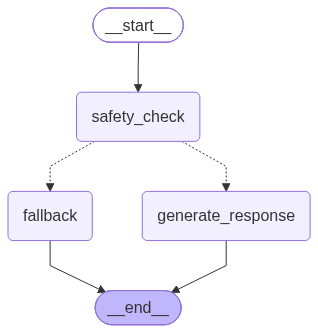

In [52]:
from IPython.display import Image

Image(graph.get_graph().draw_mermaid_png())